# Notebook 2 — Keras Custom Data Generator

In [1]:
%load_ext autotime
import shutil
import tensorflow as tf
print("TF Version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

TF Version: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
time: 8.39 s (started: 2026-03-30 22:27:27 +05:30)


In [2]:
import os
from PIL import Image
from tqdm import tqdm
import pandas as pd
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

time: 172 ms (started: 2026-03-30 22:27:35 +05:30)


In [3]:
PROJECT_ROOT = ".."
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(RAW_DIR, "class_1_agri")
dir_non_agri = os.path.join(RAW_DIR, "class_0_non_agri")
(dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

time: 0 ns (started: 2026-03-30 22:27:35 +05:30)


- Load data: collect image paths + labels (0/1)
- Shuffle: zip + `np.random.shuffle`
- Generator: `while True`, reshuffle per epoch
  - read → resize (64×64) → normalize [0,1]
  - yield (images, labels)
- Batch: size = 8
- Output: images [B,64,64,3], labels [B]
- Check: print shapes + visualize batch


In [4]:
all_image_paths = []
all_labels = []

label_non_agri = 0
label_agri = 1

for fname in os.listdir(dir_non_agri):
    all_image_paths.append(os.path.join(dir_non_agri, fname))
    all_labels.append(label_non_agri)

for fname in os.listdir(dir_agri):
    all_image_paths.append(os.path.join(dir_agri, fname))
    all_labels.append(label_agri)


time: 47 ms (started: 2026-03-30 22:27:36 +05:30)


In [5]:
temp = list(zip(all_image_paths, all_labels))
np.random.shuffle(temp)
all_image_paths, all_labels = zip(*temp)

print("First 5 paths and labels (after shuffling):", list(zip(all_image_paths[:5], all_labels[:5])))

First 5 paths and labels (after shuffling): [('..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_18610.jpg', 0), ('..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_20408.jpg', 0), ('..\\data\\raw\\images_dataSAT\\class_1_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_5202.jpg', 1), ('..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_6758.jpg', 0), ('..\\data\\raw\\images_dataSAT\\class_1_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_22482.jpg', 1)]
time: 16 ms (started: 2026-03-30 22:27:36 +05:30)


In [6]:
def custom_data_generator(image_paths, labels, batch_size, target_size=(64, 64)):
    """A custom data generator to feed a Keras model."""
    num_samples = len(image_paths)
    while True: 
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        shuffled_paths = np.array(image_paths)[indices]
        shuffled_labels = np.array(labels)[indices]
        
        for offset in range(0, num_samples, batch_size):
            batch_paths = shuffled_paths[offset:offset+batch_size]
            batch_labels = shuffled_labels[offset:offset+batch_size]
            
            batch_images = []
            for path in batch_paths:
                img = tf.keras.utils.load_img(path, target_size=target_size)
                img_array = tf.keras.utils.img_to_array(img)
                batch_images.append(img_array)
            
            yield np.array(batch_images) / 255.0, np.array(batch_labels)

time: 0 ns (started: 2026-03-30 22:27:36 +05:30)


Images batch shape: (8, 64, 64, 3)
Labels batch shape: (8,)


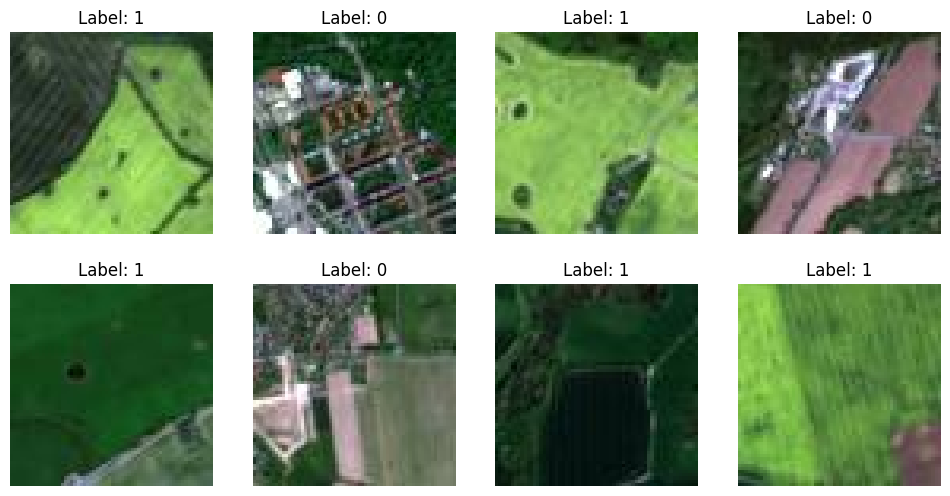

time: 906 ms (started: 2026-03-30 22:27:36 +05:30)


In [7]:
batch_size = 8
data_generator = custom_data_generator(
    image_paths=all_image_paths, 
    labels=all_labels, 
    batch_size=batch_size)
 
images, labels = next(data_generator)
 
print(f"Images batch shape: {images.shape}")
print(f"Labels batch shape: {labels.shape}")
 
plt.figure(figsize=(12, 6))
for i in range(batch_size):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")